# FRC 2024 – Autonomous Win Impact Analysis (Per-Week Breakdown)

**Objective:** Analyse how winning autonomous correlates with match wins across
the entire 2024 FRC season, broken down by week (including CMP / Einstein).
Uses `autoPoints` from the score breakdown.

**Foul Adjustment:** Match winners are determined after removing foul points from
both alliances' total scores. Matches that become ties after foul removal are excluded.
Auto ties (both alliances scored equal auto points) are also excluded.

**Data Source:** [The Blue Alliance API v3](https://www.thebluealliance.com/apidocs/v3)

In [16]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import math
import time
import os
from dotenv import load_dotenv

load_dotenv()

True

## Configuration

In [17]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────────
TBA_API_KEY = os.environ["TBA_API_KEY"]  # Loaded from .env file
YEAR        = 2024
AUTO_FIELD  = "autoPoints"  # Auto Points (Crescendo)
OFFICIAL_EVENT_TYPES = {0, 1, 2, 3, 4, 5, 6}  # exclude offseason & preseason
# ───────────────────────────────────────────────────────────────────────────────

BASE_URL = "https://www.thebluealliance.com/api/v3"
HEADERS  = {"X-TBA-Auth-Key": TBA_API_KEY}


def tba_get(endpoint: str, retries: int = 3, backoff: float = 2.0):
    url = f"{BASE_URL}{endpoint}"
    for attempt in range(retries):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=10)
            if resp.status_code == 200:
                return resp.json()
            elif resp.status_code == 429:
                wait = backoff * (attempt + 1)
                print(f"Rate limited – waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"HTTP {resp.status_code} for {url}")
                return None
        except requests.exceptions.RequestException as e:
            print(f"Request error ({attempt+1}/{retries}): {e}")
            time.sleep(backoff)
    return None


print("Configuration loaded.")

Configuration loaded.


## Step 1 – Fetch All 2024 Official Events

In [18]:
all_events = tba_get(f"/events/{YEAR}")
if not all_events:
    raise RuntimeError("Failed to fetch events list.")

# Keep only official season events
events = [
    e for e in all_events
    if e.get("event_type", 99) in OFFICIAL_EVENT_TYPES
       and (e.get("week") is not None or e.get("event_type") in {3, 4})
]

# CMP events have week=None in TBA – assign them the next week after the last regular week
max_regular_week = max((e["week"] for e in events if e.get("week") is not None), default=-1)
CMP_WEEK = max_regular_week + 1
for e in events:
    if e.get("week") is None:
        e["week"] = CMP_WEEK

# Build human-readable week labels; detect CMP / DCMP weeks
week_event_types: dict[int, set[int]] = {}
for e in events:
    week_event_types.setdefault(e["week"], set()).add(e.get("event_type", 0))

week_labels: dict[int, str] = {}
for w in sorted(week_event_types):
    if week_event_types[w] & {3, 4}:
        week_labels[w] = f"CMP (Wk {w + 1})"
    elif week_event_types[w] & {2, 5}:
        week_labels[w] = f"DCMP (Wk {w + 1})"
    else:
        week_labels[w] = f"Week {w + 1}"

print(f"Found {len(events)} official events across {len(week_labels)} weeks.\n")
for w in sorted(week_labels):
    count = sum(1 for e in events if e["week"] == w)
    print(f"  {week_labels[w]}: {count} events")

Found 190 official events across 7 weeks.

  Week 1: 32 events
  Week 2: 30 events
  Week 3: 32 events
  DCMP (Wk 4): 38 events
  Week 5: 17 events
  DCMP (Wk 6): 32 events
  CMP (Wk 7): 9 events


## Step 2 – Discover Score Breakdown Fields

Inspect the actual field names available in the 2024 match score breakdown.

In [19]:
for event in events:
    matches = tba_get(f"/event/{event['key']}/matches")
    if not matches:
        continue
    for match in matches:
        sb = match.get("score_breakdown")
        if sb and sb.get("red"):
            print(f"Sample match: {match['key']}\n")
            print("Full red alliance score breakdown:")
            print(json.dumps(sb["red"], indent=2))
            break
    else:
        continue
    break

Sample match: 2024alhu_f1m1

Full red alliance score breakdown:
{
  "adjustPoints": 0,
  "autoAmpNoteCount": 0,
  "autoAmpNotePoints": 0,
  "autoLeavePoints": 4,
  "autoLineRobot1": "No",
  "autoLineRobot2": "Yes",
  "autoLineRobot3": "Yes",
  "autoPoints": 39,
  "autoSpeakerNoteCount": 7,
  "autoSpeakerNotePoints": 35,
  "autoTotalNotePoints": 35,
  "coopNotePlayed": false,
  "coopertitionBonusAchieved": false,
  "coopertitionCriteriaMet": false,
  "endGameHarmonyPoints": 2,
  "endGameNoteInTrapPoints": 0,
  "endGameOnStagePoints": 6,
  "endGameParkPoints": 1,
  "endGameRobot1": "Parked",
  "endGameRobot2": "StageRight",
  "endGameRobot3": "StageRight",
  "endGameSpotLightBonusPoints": 0,
  "endGameTotalStagePoints": 9,
  "ensembleBonusAchieved": false,
  "ensembleBonusOnStageRobotsThreshold": 2,
  "ensembleBonusStagePointsThreshold": 10,
  "foulCount": 1,
  "foulPoints": 0,
  "g206Penalty": false,
  "g408Penalty": false,
  "g424Penalty": false,
  "melodyBonusAchieved": false,
  "melo

## Step 3 – Fetch All 2024 Match Data

In [20]:
records = []
total_events = len(events)
event_week_map = {e["key"]: e["week"] for e in events}

for idx, event in enumerate(events, start=1):
    event_key = event["key"]
    if idx % 20 == 0 or idx == total_events:
        print(f"  Fetching matches: event {idx}/{total_events} ({event_key})")

    matches = tba_get(f"/event/{event_key}/matches")
    if not matches:
        continue

    for match in matches:
        sb = match.get("score_breakdown")
        if not sb or not sb.get("red") or not sb.get("blue"):
            continue

        red_auto  = sb["red"].get(AUTO_FIELD)
        blue_auto = sb["blue"].get(AUTO_FIELD)

        if red_auto is None or blue_auto is None:
            continue

        red_total  = match["alliances"]["red"]["score"]
        blue_total = match["alliances"]["blue"]["score"]

        # Remove foul points to get foul-adjusted totals
        red_foul_pts  = sb["red"].get("foulPoints", 0)
        blue_foul_pts = sb["blue"].get("foulPoints", 0)
        red_adj  = red_total - red_foul_pts
        blue_adj = blue_total - blue_foul_pts

        # Determine winner from foul-adjusted scores; skip ties
        if red_adj > blue_adj:
            winning_alliance = "red"
        elif blue_adj > red_adj:
            winning_alliance = "blue"
        else:
            continue  # tie after foul removal – excluded

        # Determine auto winner; skip auto ties
        if red_auto > blue_auto:
            auto_winner = "red"
        elif blue_auto > red_auto:
            auto_winner = "blue"
        else:
            continue  # auto tie – excluded

        comp_level = match.get("comp_level", "")
        match_type = "qual" if comp_level == "qm" else "playoff"

        records.append({
            "event_key":        event_key,
            "match_key":        match["key"],
            "match_type":       match_type,
            "week":             event_week_map[event_key],
            "red_auto_points":  red_auto,
            "blue_auto_points": blue_auto,
            "red_total":        red_total,
            "blue_total":       blue_total,
            "red_adj_total":    red_adj,
            "blue_adj_total":   blue_adj,
            "winning_alliance": winning_alliance,
            "auto_winner":      auto_winner,
        })

    time.sleep(0.05)

df = pd.DataFrame(records)
print(f"\nCollected {len(df)} played matches across {total_events} events (foul-adjusted, auto & match ties excluded).")
for w in sorted(df["week"].unique()):
    count = len(df[df["week"] == w])
    print(f"  {week_labels[w]}: {count} matches")

  Fetching matches: event 20/190 (2024cave)
  Fetching matches: event 40/190 (2024idbo)
  Fetching matches: event 60/190 (2024mawor)
  Fetching matches: event 80/190 (2024miket)
  Fetching matches: event 100/190 (2024mokc)
  Fetching matches: event 120/190 (2024nhgrs)
  Fetching matches: event 140/190 (2024onham)
  Fetching matches: event 160/190 (2024tnkn)
  Fetching matches: event 180/190 (2024vabla)
  Fetching matches: event 190/190 (2024wimi)

Collected 16729 played matches across 190 events (foul-adjusted, ties excluded).
  Week 1: 2719 matches
  Week 2: 2501 matches
  Week 3: 2686 matches
  DCMP (Wk 4): 3374 matches
  Week 5: 1454 matches
  DCMP (Wk 6): 2868 matches
  CMP (Wk 7): 1127 matches


## Step 4 – Auto Win Percentage by Week

For matches where one alliance won autonomous (auto ties already excluded at collection),
what percentage of the time did that alliance also win the overall match (foul-adjusted)?

In [ ]:
def calc_auto_win_pct(matches_df):
    if len(matches_df) == 0:
        return 0.0, 0, 0
    wins = (matches_df["auto_winner"] == matches_df["winning_alliance"]).sum()
    total = len(matches_df)
    return wins / total * 100, wins, total


rows = []
for w in sorted(df["week"].unique()):
    week_df = df[df["week"] == w]
    pct, wins, total = calc_auto_win_pct(week_df)
    rows.append({
        "Week": week_labels[w],
        "Auto Winner Won Match": wins,
        "Total Matches": total,
        "Win %": f"{pct:.1f}%",
    })

# Overall
pct, wins, total = calc_auto_win_pct(df)
rows.append({
    "Week": "OVERALL",
    "Auto Winner Won Match": wins,
    "Total Matches": total,
    "Win %": f"{pct:.1f}%",
})

summary = pd.DataFrame(rows)
print("Match Win % for Alliances That Won Autonomous (by Week)\n")
print(summary.to_string(index=False))

Match Win % for Alliances That Won Autonomous (by Week)

       Week  Auto Winner Won Match  Total (Non-Tie Auto) Win %
     Week 1                   2050                  2538 80.8%
     Week 2                   1896                  2339 81.1%
     Week 3                   2060                  2507 82.2%
DCMP (Wk 4)                   2560                  3163 80.9%
     Week 5                   1114                  1355 82.2%
DCMP (Wk 6)                   2054                  2661 77.2%
 CMP (Wk 7)                    769                  1033 74.4%
    OVERALL                  12503                 15596 80.2%


## Step 5 – Winning Auto Score Distribution by Week

For matches where one alliance won auto, the winning auto score distribution at
10 % percentiles.

In [ ]:
percentiles = np.arange(0, 101, 10)


def percentile_table(series, label):
    values = np.percentile(series.dropna(), percentiles)
    return pd.DataFrame({
        "Percentile": [f"{p}%" for p in percentiles],
        label: [f"{v:.1f}" for v in values],
    })


decisive = df.copy()
decisive["winning_auto_score"] = decisive[["red_auto_points", "blue_auto_points"]].max(axis=1)

dist_tables = []
for w in sorted(decisive["week"].unique()):
    week_data = decisive[decisive["week"] == w]
    dist_tables.append(percentile_table(week_data["winning_auto_score"], week_labels[w]))

dist_tables.append(percentile_table(decisive["winning_auto_score"], "Overall"))

dist_df = dist_tables[0]
for t in dist_tables[1:]:
    dist_df = dist_df.merge(t, on="Percentile")

print("Winning Auto Score Distribution by Week (10% Percentiles)\n")
print(dist_df.to_string(index=False))

Winning Auto Score Distribution by Week (10% Percentiles)

Percentile Week 1 Week 2 Week 3 DCMP (Wk 4) Week 5 DCMP (Wk 6) CMP (Wk 7) Overall
        0%    2.0    2.0    2.0         4.0    2.0         2.0       12.0     2.0
       10%    9.0   10.0   12.0        14.0   14.0        19.0       24.0    12.0
       20%   14.0   14.0   16.0        17.0   17.0        24.0       29.0    16.0
       30%   16.0   16.0   19.0        19.0   19.0        26.0       31.0    19.0
       40%   17.0   19.0   21.0        22.0   22.0        29.0       31.0    22.0
       50%   19.0   21.0   24.0        24.0   24.0        29.0       34.0    24.0
       60%   22.0   22.0   24.0        26.0   26.0        31.0       36.0    26.0
       70%   24.0   24.0   27.0        29.0   29.0        34.0       39.0    29.0
       80%   26.0   27.0   29.0        31.0   31.0        36.0       41.0    31.0
       90%   31.0   31.0   34.0        34.0   34.0        39.0       46.0    36.0
      100%   54.0   56.0   51.0        

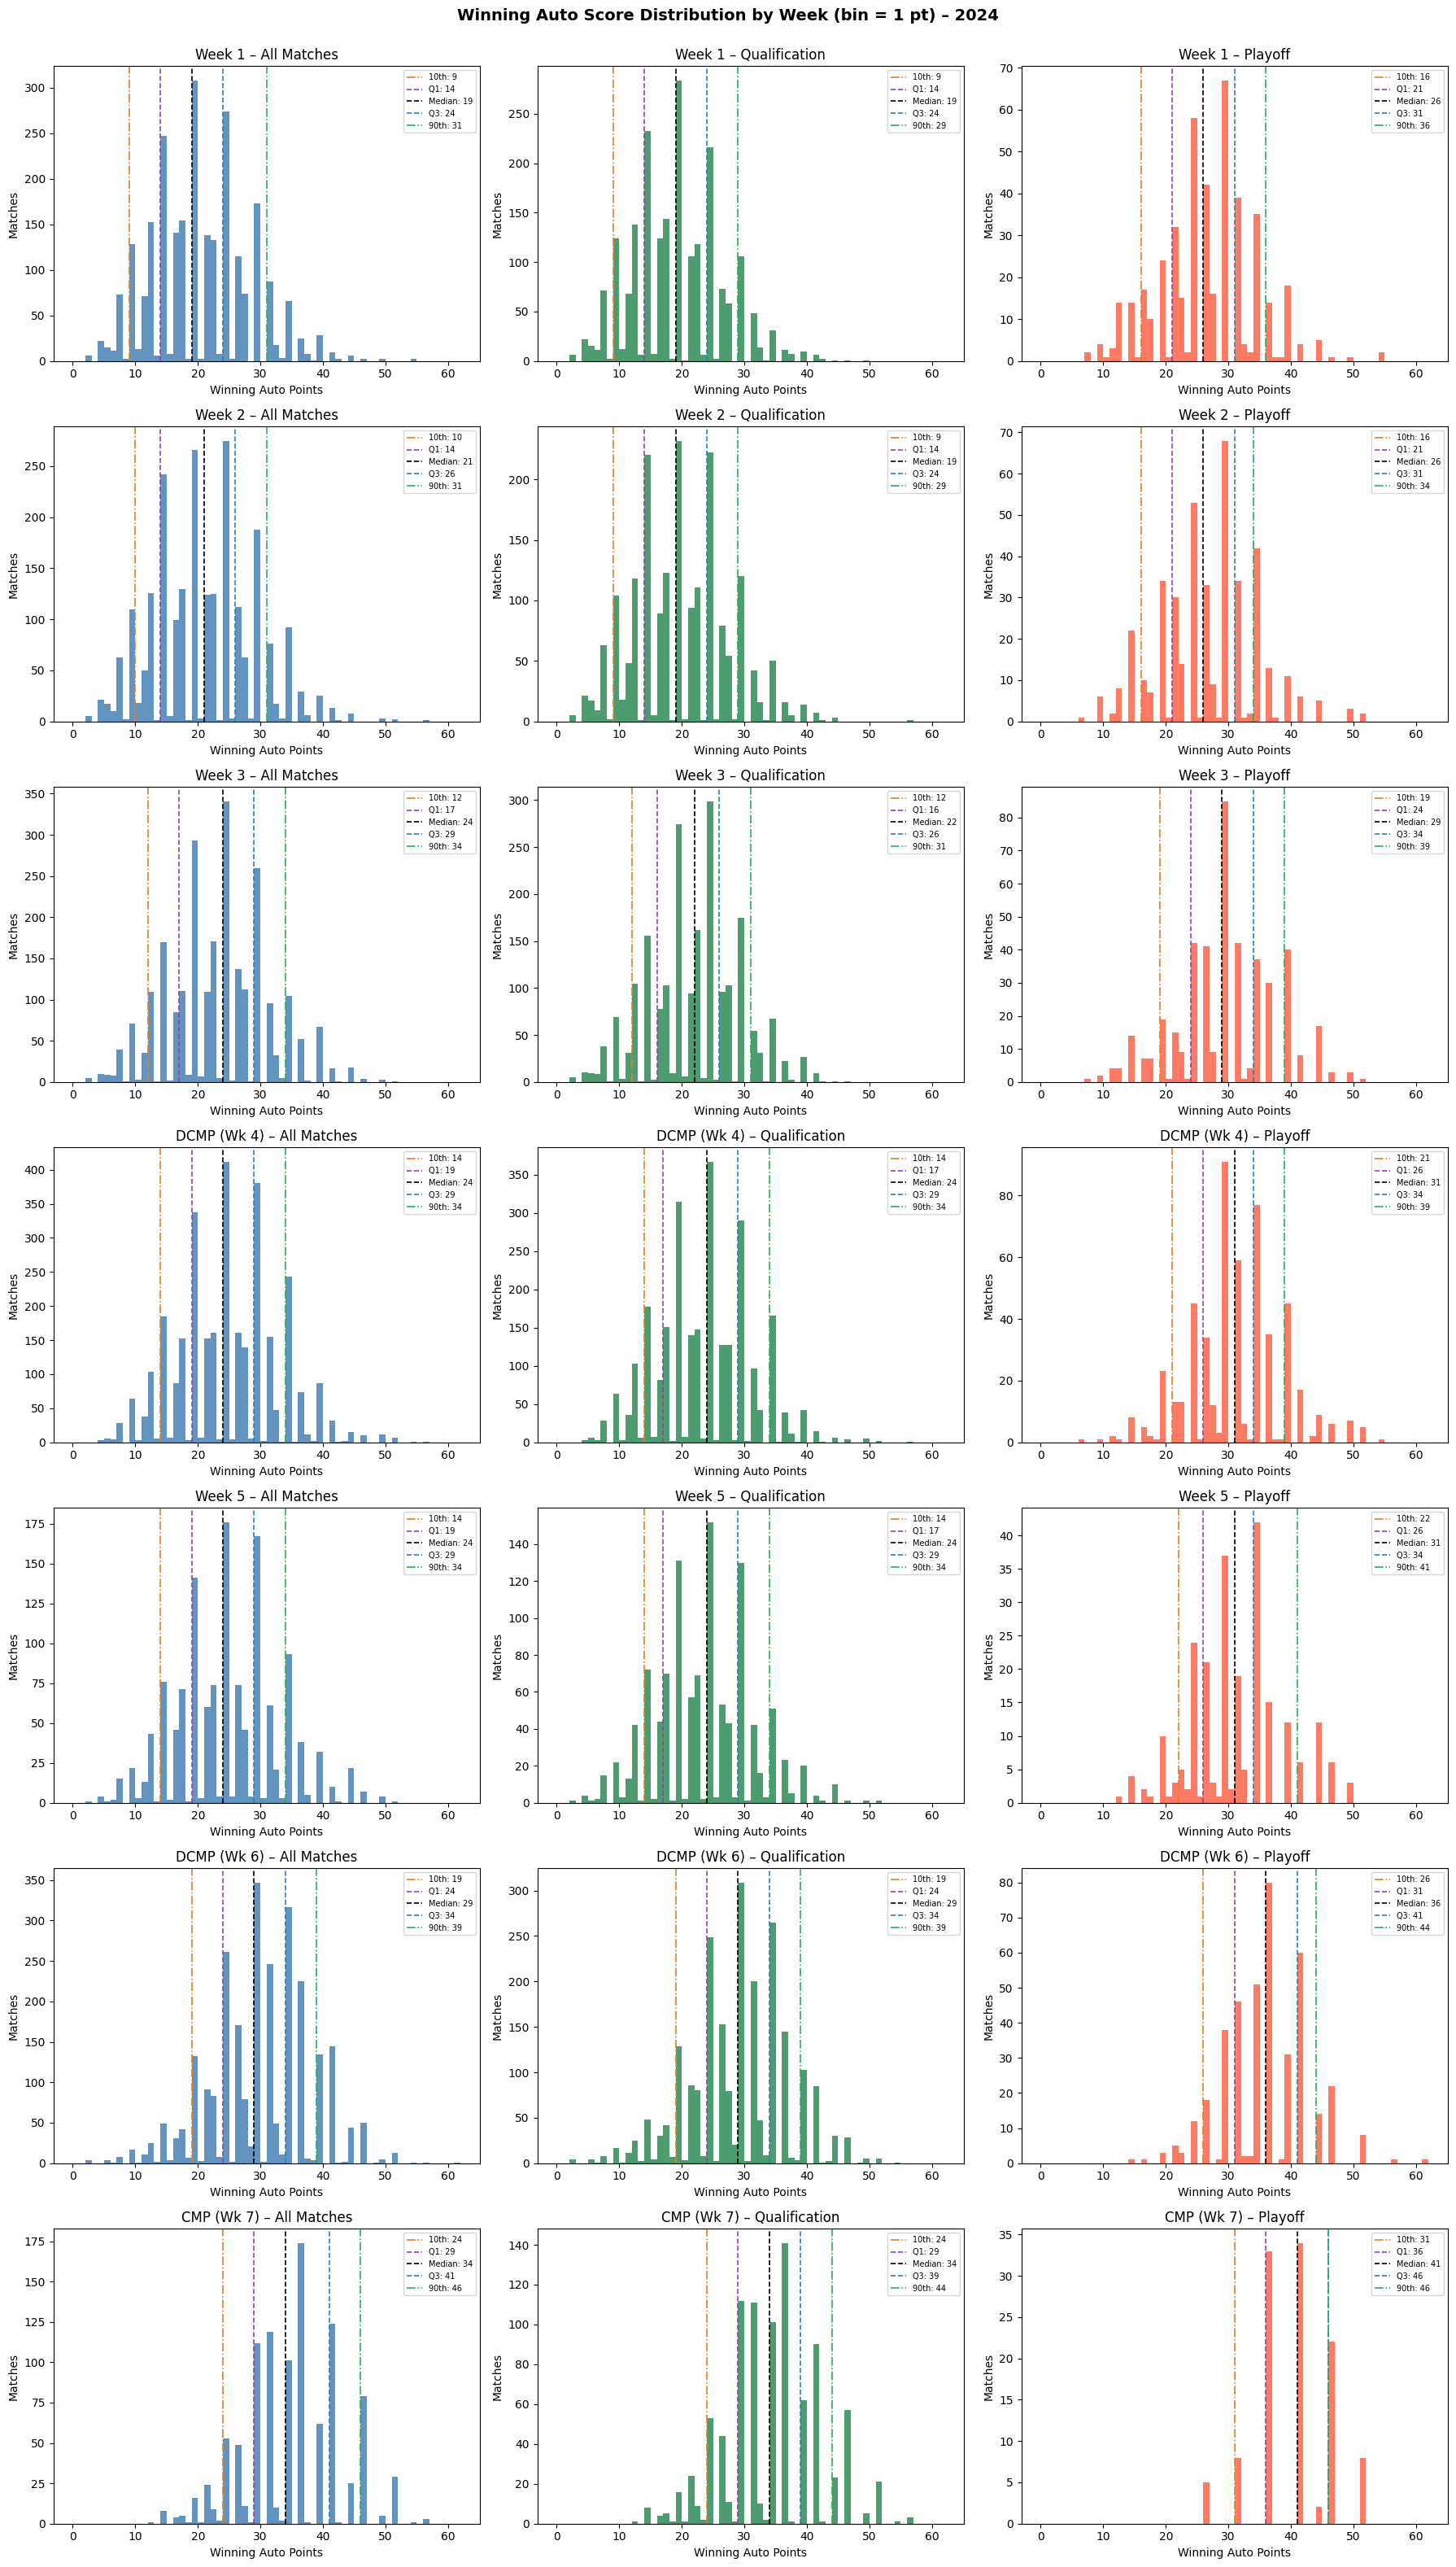

In [23]:
weeks = sorted(decisive["week"].unique())
n_weeks = len(weeks)

max_score = int(decisive["winning_auto_score"].max()) + 1
bins = np.arange(0, max_score + 1, 1)

ref_lines = [
    (10, "#e67e22", "-.", "10th"),
    (25, "#8e44ad", "--", "Q1"),
    (50, "black",   "--", "Median"),
    (75, "#2980b9", "--", "Q3"),
    (90, "#27ae60", "-.", "90th"),
]

match_subsets = [
    ("All Matches",   None,      "steelblue"),
    ("Qualification", "qual",    "seagreen"),
    ("Playoff",       "playoff", "tomato"),
]

fig, axes = plt.subplots(n_weeks, 3, figsize=(18, 4.5 * n_weeks), squeeze=False)
fig.suptitle(f"Winning Auto Score Distribution by Week (bin = 1 pt) – {YEAR}",
             fontsize=14, fontweight="bold", y=1.0)

for row_i, w in enumerate(weeks):
    week_all = decisive[decisive["week"] == w]
    for col_j, (label, mtype, color) in enumerate(match_subsets):
        ax = axes[row_i][col_j]
        data = week_all if mtype is None else week_all[week_all["match_type"] == mtype]
        if data.empty:
            ax.set_title(f"{week_labels[w]} – {label} (no data)")
            ax.set_visible(True)
            continue
        ax.hist(data["winning_auto_score"], bins=bins, color=color, edgecolor="none", alpha=0.85)
        ax.set_title(f"{week_labels[w]} – {label}")
        ax.set_xlabel("Winning Auto Points")
        ax.set_ylabel("Matches")
        for pct, lc, ls, lbl in ref_lines:
            val = np.percentile(data["winning_auto_score"], pct)
            ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

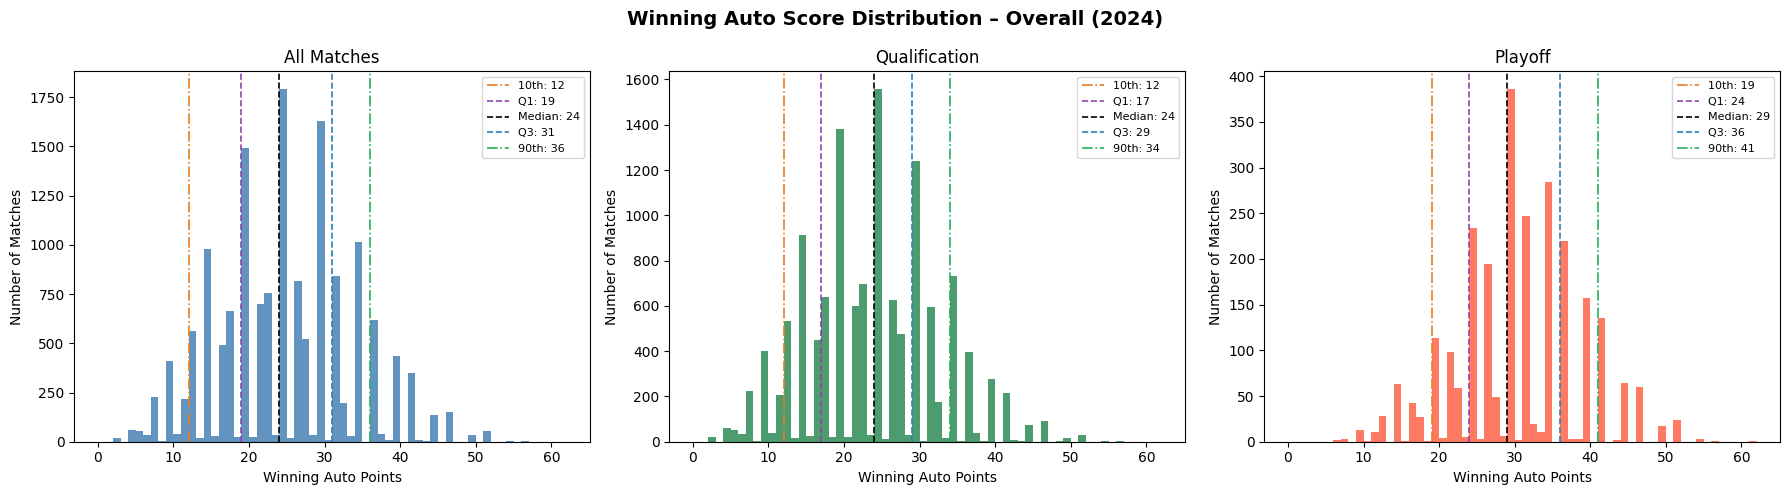

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle(f"Winning Auto Score Distribution – Overall ({YEAR})",
             fontsize=14, fontweight="bold")

subsets = [
    (decisive,                                      "All Matches",   "steelblue"),
    (decisive[decisive["match_type"] == "qual"],    "Qualification", "seagreen"),
    (decisive[decisive["match_type"] == "playoff"], "Playoff",       "tomato"),
]

for ax, (data, title, color) in zip(axes, subsets):
    ax.hist(data["winning_auto_score"], bins=bins, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Winning Auto Points")
    ax.set_ylabel("Number of Matches")
    for pct, lc, ls, lbl in ref_lines:
        val = np.percentile(data["winning_auto_score"], pct)
        ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 6 – Auto Win Margin Distribution by Week

The win margin is the difference in auto points between the winning and losing alliance.

In [25]:
decisive["auto_margin"] = (
    decisive[["red_auto_points", "blue_auto_points"]].max(axis=1)
    - decisive[["red_auto_points", "blue_auto_points"]].min(axis=1)
)

margin_tables = []
for w in sorted(decisive["week"].unique()):
    week_data = decisive[decisive["week"] == w]
    margin_tables.append(percentile_table(week_data["auto_margin"], week_labels[w]))

margin_tables.append(percentile_table(decisive["auto_margin"], "Overall"))

margin_df = margin_tables[0]
for t in margin_tables[1:]:
    margin_df = margin_df.merge(t, on="Percentile")

print("Auto Win Margin Distribution by Week (10% Percentiles)\n")
print(margin_df.to_string(index=False))

Auto Win Margin Distribution by Week (10% Percentiles)

Percentile Week 1 Week 2 Week 3 DCMP (Wk 4) Week 5 DCMP (Wk 6) CMP (Wk 7) Overall
        0%    1.0    1.0    1.0         1.0    1.0         1.0        1.0     1.0
       10%    2.0    2.0    2.0         2.0    2.0         2.0        3.0     2.0
       20%    3.0    4.0    5.0         4.0    4.0         5.0        5.0     4.0
       30%    5.0    5.0    5.0         5.0    5.0         5.0        5.0     5.0
       40%    7.0    7.0    7.0         7.0    7.0         7.0        8.0     7.0
       50%    8.0    8.0    9.0         9.0   10.0        10.0       10.0     9.0
       60%   10.0   10.0   10.0        10.0   11.0        11.0       10.2    10.0
       70%   12.0   12.0   13.0        13.0   13.8        13.0       13.4    13.0
       80%   15.0   15.0   17.0        17.0   17.0        17.0       17.0    15.0
       90%   19.0   19.0   20.0        20.0   20.0        20.0       22.0    20.0
      100%   47.0   47.0   37.0        44.

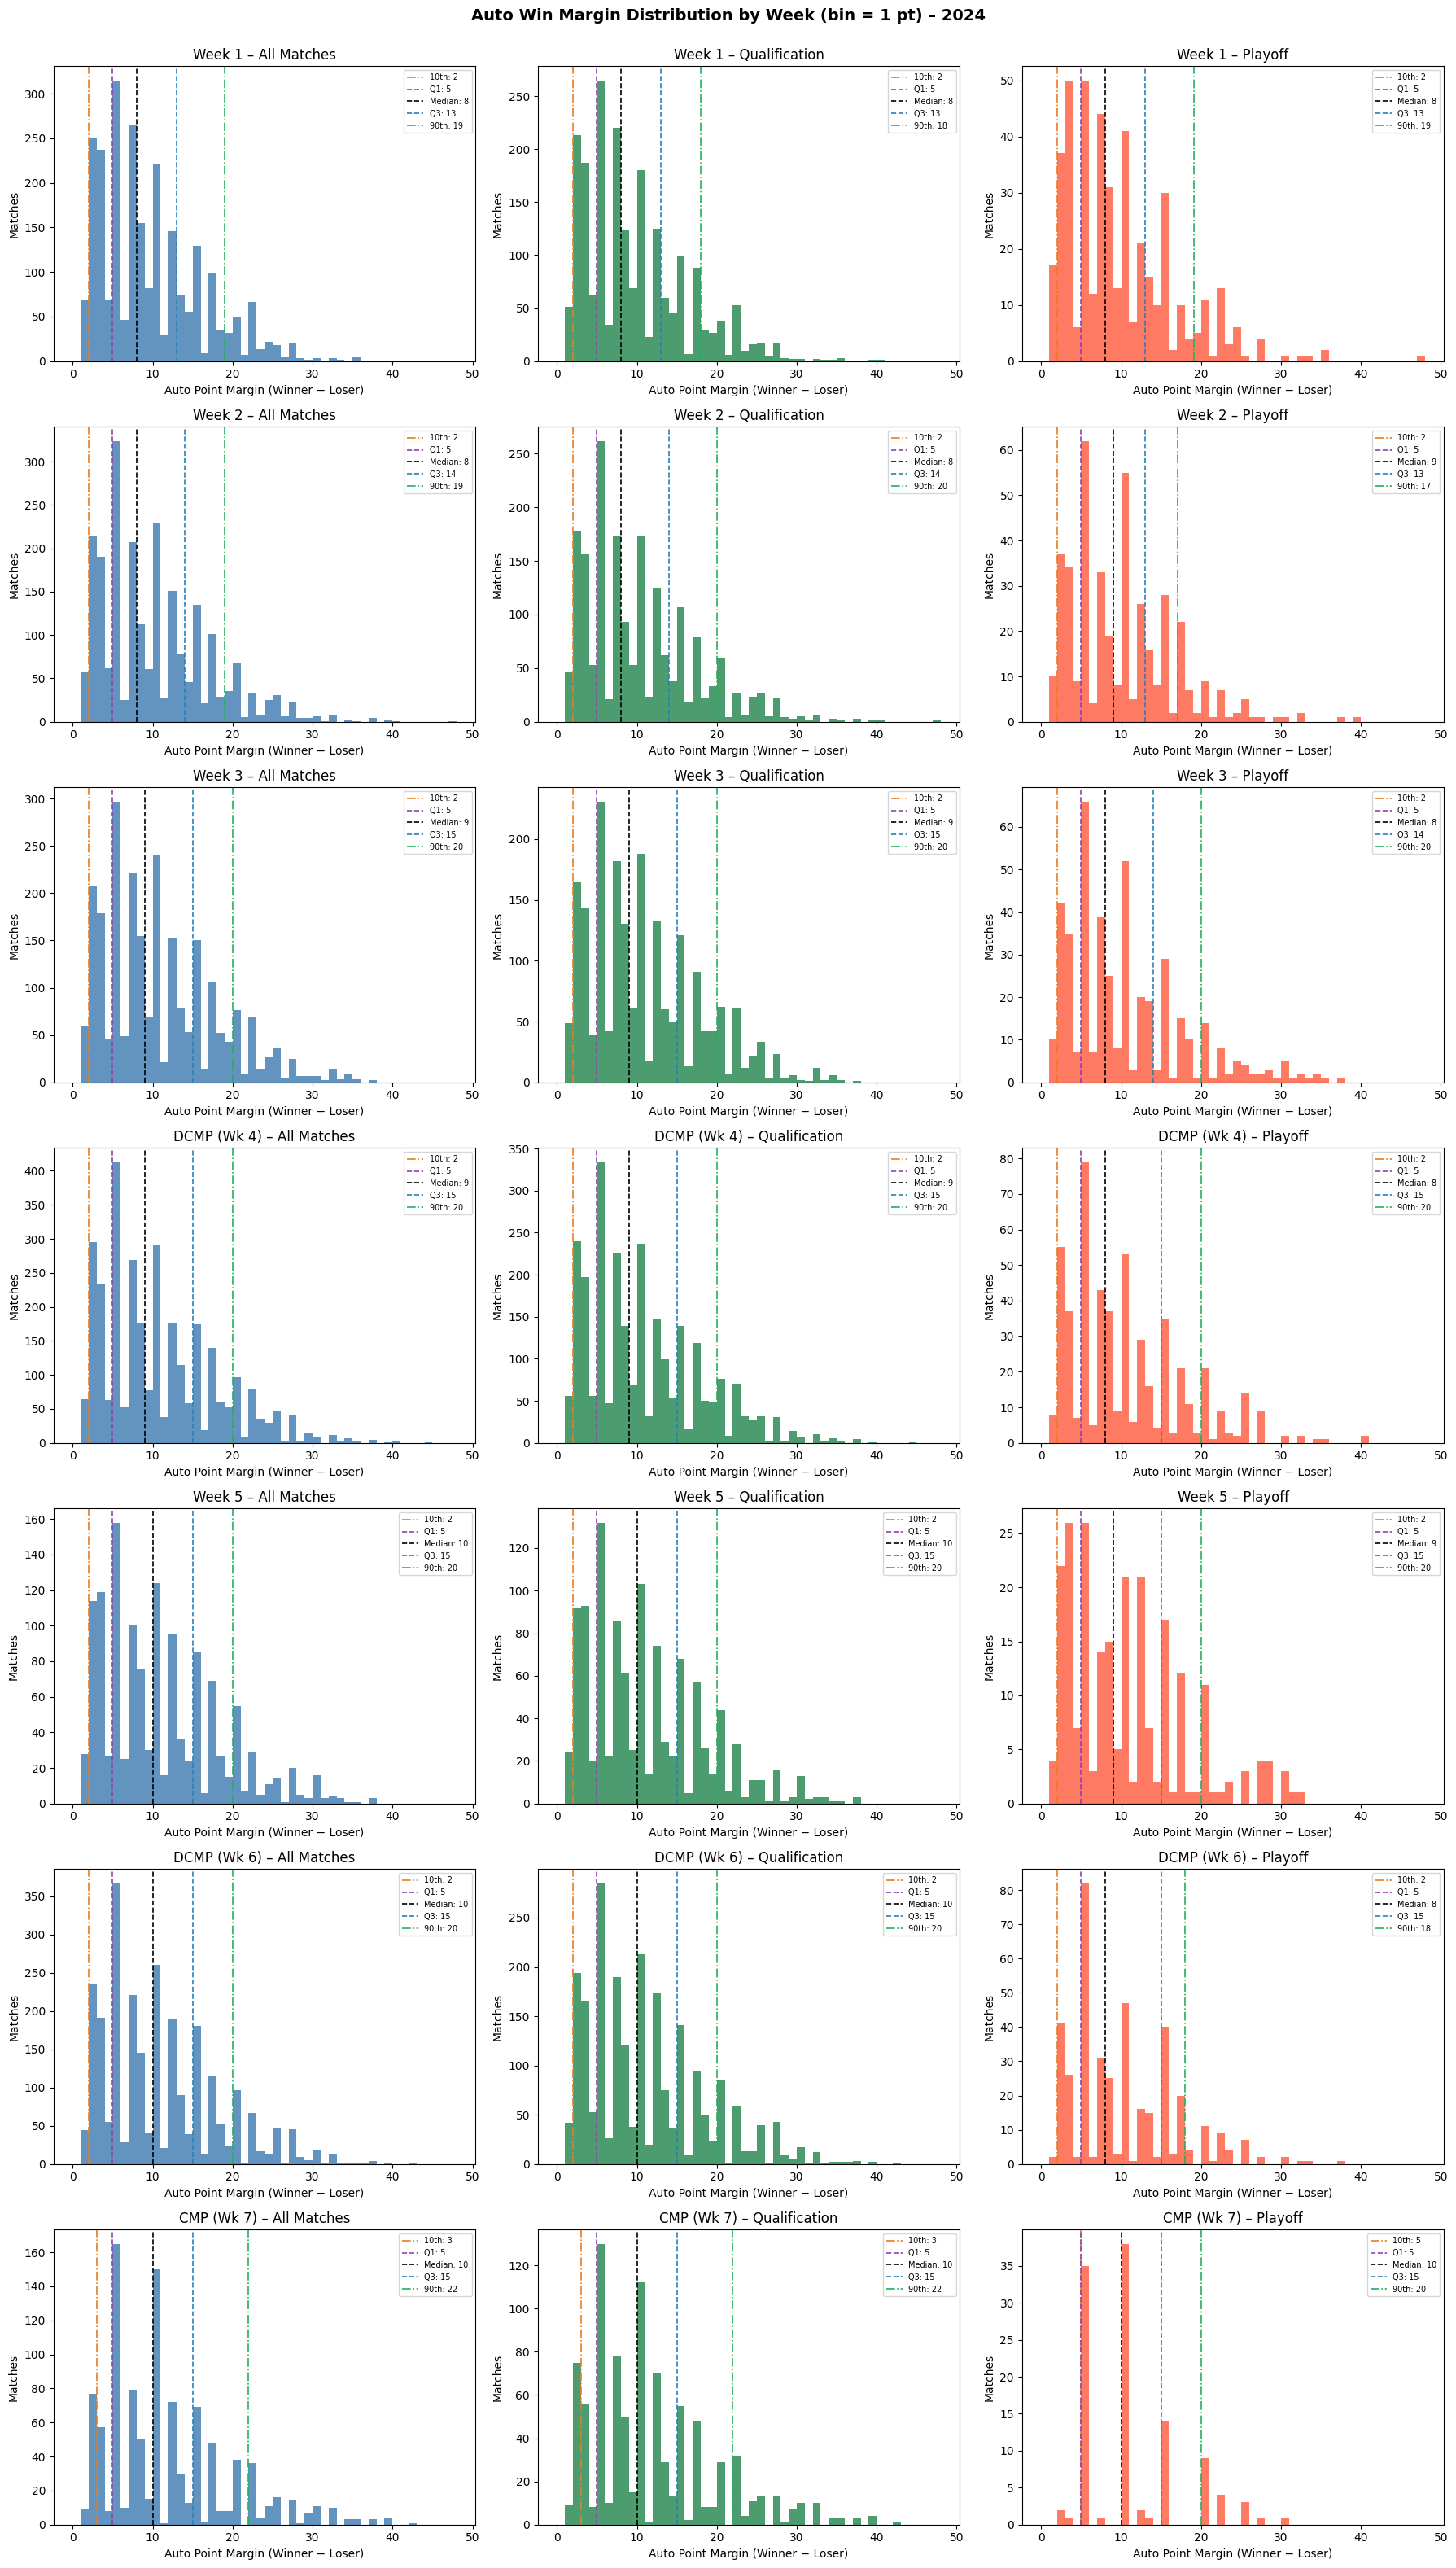

In [26]:
max_margin = int(decisive["auto_margin"].max()) + 1
bins_margin = np.arange(0, max_margin + 1, 1)

match_subsets = [
    ("All Matches",   None,      "steelblue"),
    ("Qualification", "qual",    "seagreen"),
    ("Playoff",       "playoff", "tomato"),
]

fig, axes = plt.subplots(n_weeks, 3, figsize=(18, 4.5 * n_weeks), squeeze=False)
fig.suptitle(f"Auto Win Margin Distribution by Week (bin = 1 pt) – {YEAR}",
             fontsize=14, fontweight="bold", y=1.0)

for row_i, w in enumerate(weeks):
    week_all = decisive[decisive["week"] == w]
    for col_j, (label, mtype, color) in enumerate(match_subsets):
        ax = axes[row_i][col_j]
        data = week_all if mtype is None else week_all[week_all["match_type"] == mtype]
        if data.empty:
            ax.set_title(f"{week_labels[w]} – {label} (no data)")
            ax.set_visible(True)
            continue
        ax.hist(data["auto_margin"], bins=bins_margin, color=color, edgecolor="none", alpha=0.85)
        ax.set_title(f"{week_labels[w]} – {label}")
        ax.set_xlabel("Auto Point Margin (Winner − Loser)")
        ax.set_ylabel("Matches")
        for pct, lc, ls, lbl in ref_lines:
            val = np.percentile(data["auto_margin"], pct)
            ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

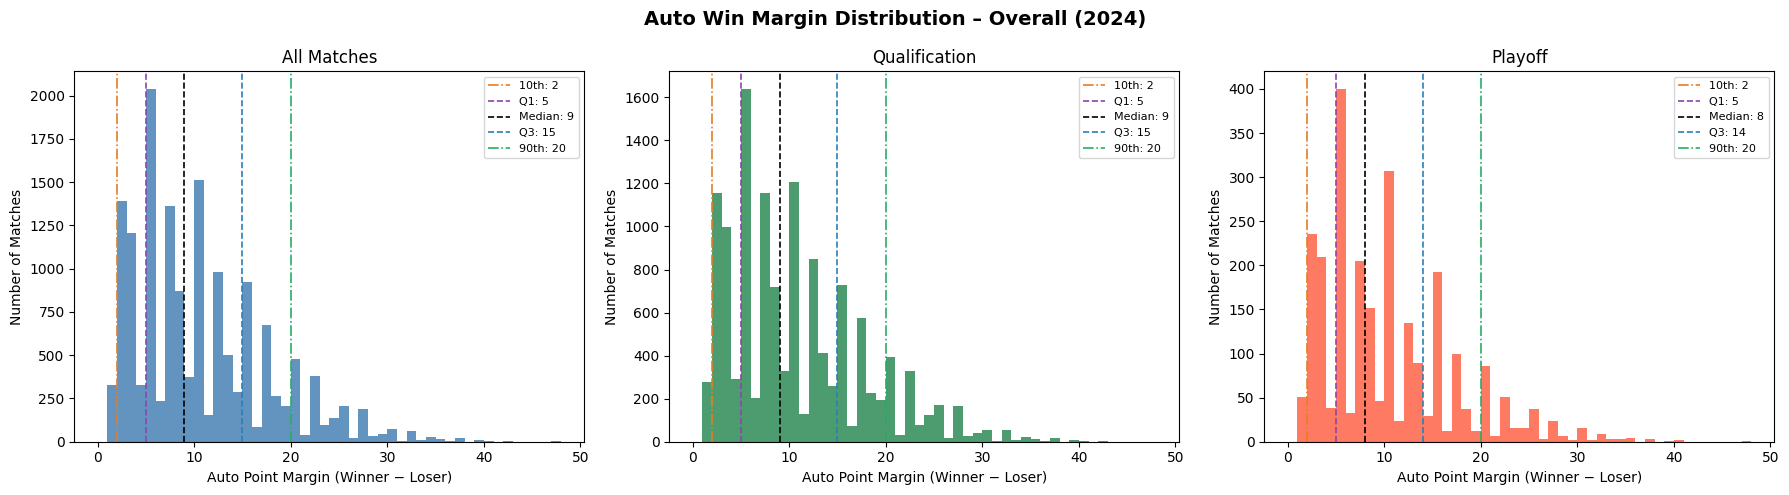

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle(f"Auto Win Margin Distribution – Overall ({YEAR})",
             fontsize=14, fontweight="bold")

subsets = [
    (decisive,                                      "All Matches",   "steelblue"),
    (decisive[decisive["match_type"] == "qual"],    "Qualification", "seagreen"),
    (decisive[decisive["match_type"] == "playoff"], "Playoff",       "tomato"),
]

for ax, (data, title, color) in zip(axes, subsets):
    ax.hist(data["auto_margin"], bins=bins_margin, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Auto Point Margin (Winner − Loser)")
    ax.set_ylabel("Number of Matches")
    for pct, lc, ls, lbl in ref_lines:
        val = np.percentile(data["auto_margin"], pct)
        ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
def print_100th_percentile_matches(decisive_df, score_col, label):
    max_val = decisive_df[score_col].max()
    matches = decisive_df[decisive_df[score_col] == max_val][
        ["match_key", "event_key", "week", "red_auto_points", "blue_auto_points", "winning_alliance"]
    ].copy()
    print(f"── 100th Percentile: {label} = {max_val:.0f} ─────────────────")
    for _, row in matches.iterrows():
        winner_side = "Red" if row["red_auto_points"] > row["blue_auto_points"] else "Blue"
        print(f"  Match:    {row['match_key']}")
        print(f"  Event:    {row['event_key']} ({week_labels[row['week']]})")
        print(f"  Alliance: {winner_side}")
        print(f"  Red auto pts: {row['red_auto_points']}   Blue auto pts: {row['blue_auto_points']}")
        print(f"  Match winner: {row['winning_alliance'].capitalize()}")
        print()


print_100th_percentile_matches(decisive, "winning_auto_score", "Winning Auto Score")
print_100th_percentile_matches(decisive, "auto_margin", "Auto Win Margin")

── 100th Percentile: Winning Auto Score = 61 ─────────────────
  Match:    2024gacmp_f1m2
  Event:    2024gacmp (DCMP (Wk 6))
  Alliance: Red
  Red auto pts: 61   Blue auto pts: 29
  Match winner: Red

── 100th Percentile: Auto Win Margin = 47 ─────────────────
  Match:    2024isde1_sf1m1
  Event:    2024isde1 (Week 1)
  Alliance: Red
  Red auto pts: 54   Blue auto pts: 7
  Match winner: Red

  Match:    2024tuis2_qm43
  Event:    2024tuis2 (Week 2)
  Alliance: Blue
  Red auto pts: 9   Blue auto pts: 56
  Match winner: Blue

